# **Project 1 - Sales Analysis - ETL**

## Objectives

- Extract data from provided CSV files
- Clean it 
- Apply feature engineering if necessary 
- Remove any unnecessary columns
- Save to a new CSV file


## Inputs

CSV files provided:

stores data-set.csv
sales data-set.csv
features data set.csv

Renamed files to a uniform naming convention:

Sales_Features_DataSet.csv
Sales_DataSet.csv
Sales_Stores_DataSet.csv

Note: original files are stored in Data/OriginalFiles


## Outputs

CSV file created from ETL etc stored in Data:

Sales_Combined.csv



## Additional Comments

Had an error trying to use pip install - r requirements.txt 

So initally manually installed:

numpy
pandas
seaborn
plotly
seaborn
matplotlib

THEN after checking with course fascilitator needed to remove ppscore from the requirements.txt file
This produced another error which I tracked down to being ydata-profiling so removed that as well
Re-installed dependancies from the requirements.txt file - works fine.

## Initalise Working Environment

In [17]:
#import libraries
import os
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
#added by me for visualisation fine tuning
from matplotlib.ticker import MultipleLocator


# Section 1 - Initalisation

## Intitialise All Variables To Be Used In Global Stack 

In [3]:
#DataFrame vars for ETL
dfSales_Features_DataSet = None
dfSales_Stores_DataSet = None
dfSales_DataSet = None
dfSales_Combined = None
dfTemp = None

#stores current directory
strCurrentDir = ""

#constant for project directory
CNST_STR_PROJECT_DIR = "Project1-SalesAnalysis"

#file path constants
CNST_STR_SALESCOMBINEDFILEPATH = "/Data/VisualisationDataSet/Sales_Combined.csv"
CNST_STR_SALESFILEPATH = "/Data/CleanedDataSets/Sales_DataSet_Cleaned.csv"
CNST_STR_SALESFEATURESFILEPATH = "/Data/CleanedDataSets/Sales_Features_DataSet_Cleaned.csv"
CNST_STR_SALESSTORESFILEPATH = "/Data/CleanedDataSets/Sales_Stores_DataSet_Cleaned.csv"

#other vars
objColumns = None
lstColumns = []
dictColumns = {}


## Set Current Directory To Base Project Directory

In [4]:
#get project directory - default is jupyter notebook sub folder as that is where this file is located!
#so move back one to the project root path
# Source - https://stackoverflow.com/a/17726833
# Posted by chimpsarehungry
# Retrieved 2026-07-05, License - CC BY-SA 3.0

#get current folder
strCurrentDir = os.getcwd()

#is the last part of the path the project directory?
if not strCurrentDir.endswith(CNST_STR_PROJECT_DIR):
   #get current working directory and move back one to the project root path
   strCurrentDir =  os.path.normpath(os.getcwd() + os.sep + os.pardir)
   os.chdir(os.path.dirname(strCurrentDir))
   #change directory
   os.chdir(strCurrentDir)

#confirm current directory is project directory
print(f"Current Directory: \n {os.getcwd()}")

Current Directory: 
 /Users/rogerwilliams/Projects/Python/CourseProjects/Project1-SalesAnalysis


# Section 1 - Combination

- Read csv files
- Combine into one DataFrame

## Read csv Files Into Variable For Processing

In [5]:
#read csv files into DataFrames
dfSales_Features_DataSet = pd.read_csv(strCurrentDir + CNST_STR_SALESFEATURESFILEPATH)
dfSales_DataSet = pd.read_csv(strCurrentDir + CNST_STR_SALESFILEPATH)
dfSales_Stores_DataSet = pd.read_csv(strCurrentDir + CNST_STR_SALESSTORESFILEPATH)

## Combine The Data Frames!

## How The DataFrames Are Related

_"primary key"_  
dfSales_Stores_DataSet Has One Common Column: Store  
dfSales_DataSet Has One Common Column With dfSales_Stores_DataSet: Store  
dfSales_Features_DataSet Has One Common Column With dfSales_Stores_DataSet: Store  

_Columns Shared Between dfSales_DataSet And dfSales_Features_DataSet:_    
Store, Date

Combined Columns To Use For Analysis:  
Store: int64
Date: datetime64[us]
Size: int64
Temperature: float64
Dept: int64
Weekly_Sales: float64
IsHoliday: bool
MarkDown1: float64
MarkDown2: float64
MarkDown3: float64
MarkDown4: float64
MarkDown5: float64
StoreType: int64 <- Feature Engineering addition to Sales_Stores_DataSet.csv>


In [6]:
#first convert the Date columns to datetime format
dfSales_DataSet["Date"] = pd.to_datetime(dfSales_DataSet["Date"], format="%d/%m/%Y")
dfSales_Features_DataSet["Date"] = pd.to_datetime(dfSales_Features_DataSet["Date"], format="%d/%m/%Y")

# combine DataFrames
dfCombined_DataSet = pd.merge(dfSales_DataSet, dfSales_Features_DataSet, on=['Store', 'Date'], how='left')
#dfCombined = pd.merge(dfCombined, dfSales_Stores_DataSet, on='Store', how='left')
# Merge Sales and Features
dfCombined_DataSet = pd.merge(
    dfSales_DataSet,
    dfSales_Features_DataSet,
    on=["Store", "Date"],
    how="left",
    indicator = True
)

# Merge the result with Stores

dfCombined_DataSet = pd.merge(
    dfCombined_DataSet,
    dfSales_Stores_DataSet,
    on="Store",
    how="left"
)

#show results
dfCombined_DataSet.head(30000)




,Store,Date,Weekly_Sales,IsHoliday_x,Temperature,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,IsHoliday_y,_merge,Unnamed: 0,Size,StoreType
0,1,2010-02-05,24924.50,False,42.31,0.0,0.0,0.0,0.0,0.0,False,both,0,151315,1
1,1,2010-02-12,46039.49,True,38.51,0.0,0.0,0.0,0.0,0.0,True,both,0,151315,1
2,1,2010-02-19,41595.55,False,39.93,0.0,0.0,0.0,0.0,0.0,False,both,0,151315,1
3,1,2010-02-26,19403.54,False,46.63,0.0,0.0,0.0,0.0,0.0,False,both,0,151315,1
4,1,2010-03-05,21827.90,False,46.50,0.0,0.0,0.0,0.0,0.0,False,both,0,151315,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,4,2011-01-07,56671.32,False,39.34,0.0,0.0,0.0,0.0,0.0,False,both,3,205863,1
29996,4,2011-01-14,54969.55,False,31.60,0.0,0.0,0.0,0.0,0.0,False,both,3,205863,1
29997,4,2011-01-21,55157.31,False,38.34,0.0,0.0,0.0,0.0,0.0,False,both,3,205863,1
29998,4,2011-01-28,51712.45,False,40.60,0.0,0.0,0.0,0.0,0.0,False,both,3,205863,1


## Observations - Sales_Combined_DataSet

Checks:

Checked Column vale change for Markdown1 at page: 81 to check if had value: 10382.9
as per the raw csv file.

Checked column value change for Store at page: 2049 to check if StoreType column
was correctly showing the value 2 when the Store column value was 3 as in the 
dfSales_Store_DataSet DataFrame Store value 3 = store type B which in the new column
added during data transformation in Notebook_ETL_Sales_Stores_DataSet.ipynb is 2

All values found as expected.

## Observations - Sales_Combined_DataSet
Check new DataFrame schema

In [7]:
#check new DataFrame schema
dfCombined_DataSet.dtypes


Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday_x               bool
Temperature            float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
IsHoliday_y               bool
_merge                category
Unnamed: 0               int64
Size                     int64
StoreType                int64
dtype: object

## Observations - Sales_Combined_DataSet

Columns count correct, need to rename some delete others before visualisation

---

# Section 2 - Transformation

- Delete unnecessary columns
- Rename any columns if necessary

Columns to renove (All created by Pandas merge method):
_merge
IsHoliday_y
Unnamed: 0 


Columns To Rename:
IsHoliday_x -> IsHoliday



In [8]:
#delete unnecessary columns  
dfCombined_DataSet.drop(columns=["_merge", "IsHoliday_y", "Unnamed: 0"], inplace=True)

#check results
dfCombined_DataSet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Date          421570 non-null  datetime64[ns]
 2   Weekly_Sales  421570 non-null  float64       
 3   IsHoliday_x   421570 non-null  bool          
 4   Temperature   421570 non-null  float64       
 5   MarkDown1     421570 non-null  float64       
 6   MarkDown2     421570 non-null  float64       
 7   MarkDown3     421570 non-null  float64       
 8   MarkDown4     421570 non-null  float64       
 9   MarkDown5     421570 non-null  float64       
 10  Size          421570 non-null  int64         
 11  StoreType     421570 non-null  int64         
dtypes: bool(1), datetime64[ns](1), float64(7), int64(3)
memory usage: 35.8 MB


## Observations - Combined_DataSet

Schema as eExpected

## Observations - Rename Columns

In [9]:
#rename columns: IsHoliday_x -> IsHoliday StoreType -> Store_Type  Size_x -> Store_Size
dfCombined_DataSet.rename(columns={'IsHoliday_x': 'IsHoliday', 'StoreType': 'Store_Type', 'Size': 'Store_Size'}, inplace=True)

#check results
dfCombined_DataSet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Date          421570 non-null  datetime64[ns]
 2   Weekly_Sales  421570 non-null  float64       
 3   IsHoliday     421570 non-null  bool          
 4   Temperature   421570 non-null  float64       
 5   MarkDown1     421570 non-null  float64       
 6   MarkDown2     421570 non-null  float64       
 7   MarkDown3     421570 non-null  float64       
 8   MarkDown4     421570 non-null  float64       
 9   MarkDown5     421570 non-null  float64       
 10  Store_Size    421570 non-null  int64         
 11  Store_Type    421570 non-null  int64         
dtypes: bool(1), datetime64[ns](1), float64(7), int64(3)
memory usage: 35.8 MB


## Observations - Combined_DataSet

Schema as expected

## Check For Missing Values (Paranoia)

In [10]:
#get total missing values
intMissing = dfCombined_DataSet.isnull().sum()

#calculate percent missing
intMissingPercent = ( intMissing / len(dfCombined_DataSet) * 100)
dfCheck = pd.DataFrame( {"Missing Values": intMissing, "%" : intMissingPercent})

#show results
if dfCheck["Missing Values"].sum() !=0:
   print( dfCheck[dfCheck["Missing Values"] > 0])
else:
   print( "No Missing Values")     


No Missing Values


## Observations - Combined_DataSet

No Missing Values - Phew!

---

## Data Transformations/Feature Engineering

Had Mad Scientist idea:

Create a column with just year and month in it, if i get time (and if its actually feasible)
Might be able to knock some visualsations by month...

In [11]:
#create a column with JUST year and month as integer
dfCombined_DataSet["YearMonth"] = dfCombined_DataSet["Date"].dt.strftime('%Y%m').astype(int)

#check results
dfCombined_DataSet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Date          421570 non-null  datetime64[ns]
 2   Weekly_Sales  421570 non-null  float64       
 3   IsHoliday     421570 non-null  bool          
 4   Temperature   421570 non-null  float64       
 5   MarkDown1     421570 non-null  float64       
 6   MarkDown2     421570 non-null  float64       
 7   MarkDown3     421570 non-null  float64       
 8   MarkDown4     421570 non-null  float64       
 9   MarkDown5     421570 non-null  float64       
 10  Store_Size    421570 non-null  int64         
 11  Store_Type    421570 non-null  int64         
 12  YearMonth     421570 non-null  int64         
dtypes: bool(1), datetime64[ns](1), float64(7), int64(4)
memory usage: 39.0 MB


## Observations - Combined_DataSet

Schema as expected

## Check Data In New Column

In [12]:
#check data
dfCombined_DataSet.head(50)

,Store,Date,Weekly_Sales,IsHoliday,Temperature,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Store_Size,Store_Type,YearMonth
0,1,2010-02-05,24924.50,False,42.31,0.0,0.0,0.0,0.0,0.0,151315,1,201002
1,1,2010-02-12,46039.49,True,38.51,0.0,0.0,0.0,0.0,0.0,151315,1,201002
2,1,2010-02-19,41595.55,False,39.93,0.0,0.0,0.0,0.0,0.0,151315,1,201002
3,1,2010-02-26,19403.54,False,46.63,0.0,0.0,0.0,0.0,0.0,151315,1,201002
4,1,2010-03-05,21827.90,False,46.50,0.0,0.0,0.0,0.0,0.0,151315,1,201003
5,1,2010-03-12,21043.39,False,57.79,0.0,0.0,0.0,0.0,0.0,151315,1,201003
6,1,2010-03-19,22136.64,False,54.58,0.0,0.0,0.0,0.0,0.0,151315,1,201003
7,1,2010-03-26,26229.21,False,51.45,0.0,0.0,0.0,0.0,0.0,151315,1,201003
8,1,2010-04-02,57258.43,False,62.27,0.0,0.0,0.0,0.0,0.0,151315,1,201004
9,1,2010-04-09,42960.91,False,65.86,0.0,0.0,0.0,0.0,0.0,151315,1,201004


## Observations - Combined_DataSet

Data as expected

## Save Combined DataFrame To CSV File

In [13]:
#save dfCombined_DataSet to csv file with chatGPT suggested options
dfCombined_DataSet.to_csv(strCurrentDir + CNST_STR_SALESCOMBINEDFILEPATH, date_format="%d/%m/%Y")

#Note: probably don't need to save the DataFrame, just being systematic
#      undoubtedly if I load the combines csv file I will have to transform
#      the Date field back into a datetime column!

# Next Steps

End of ETL process. Now visualising the hypothesis can begin!

## Visualisations!

Each hypothesis will be visualised using:

- matplotlib.pyplot
- plotly.express
- seaborn


## Hypothesis 1

Are sales increased if weather is hotter or colder? 
Visualisation library: matplotlib.pyplot

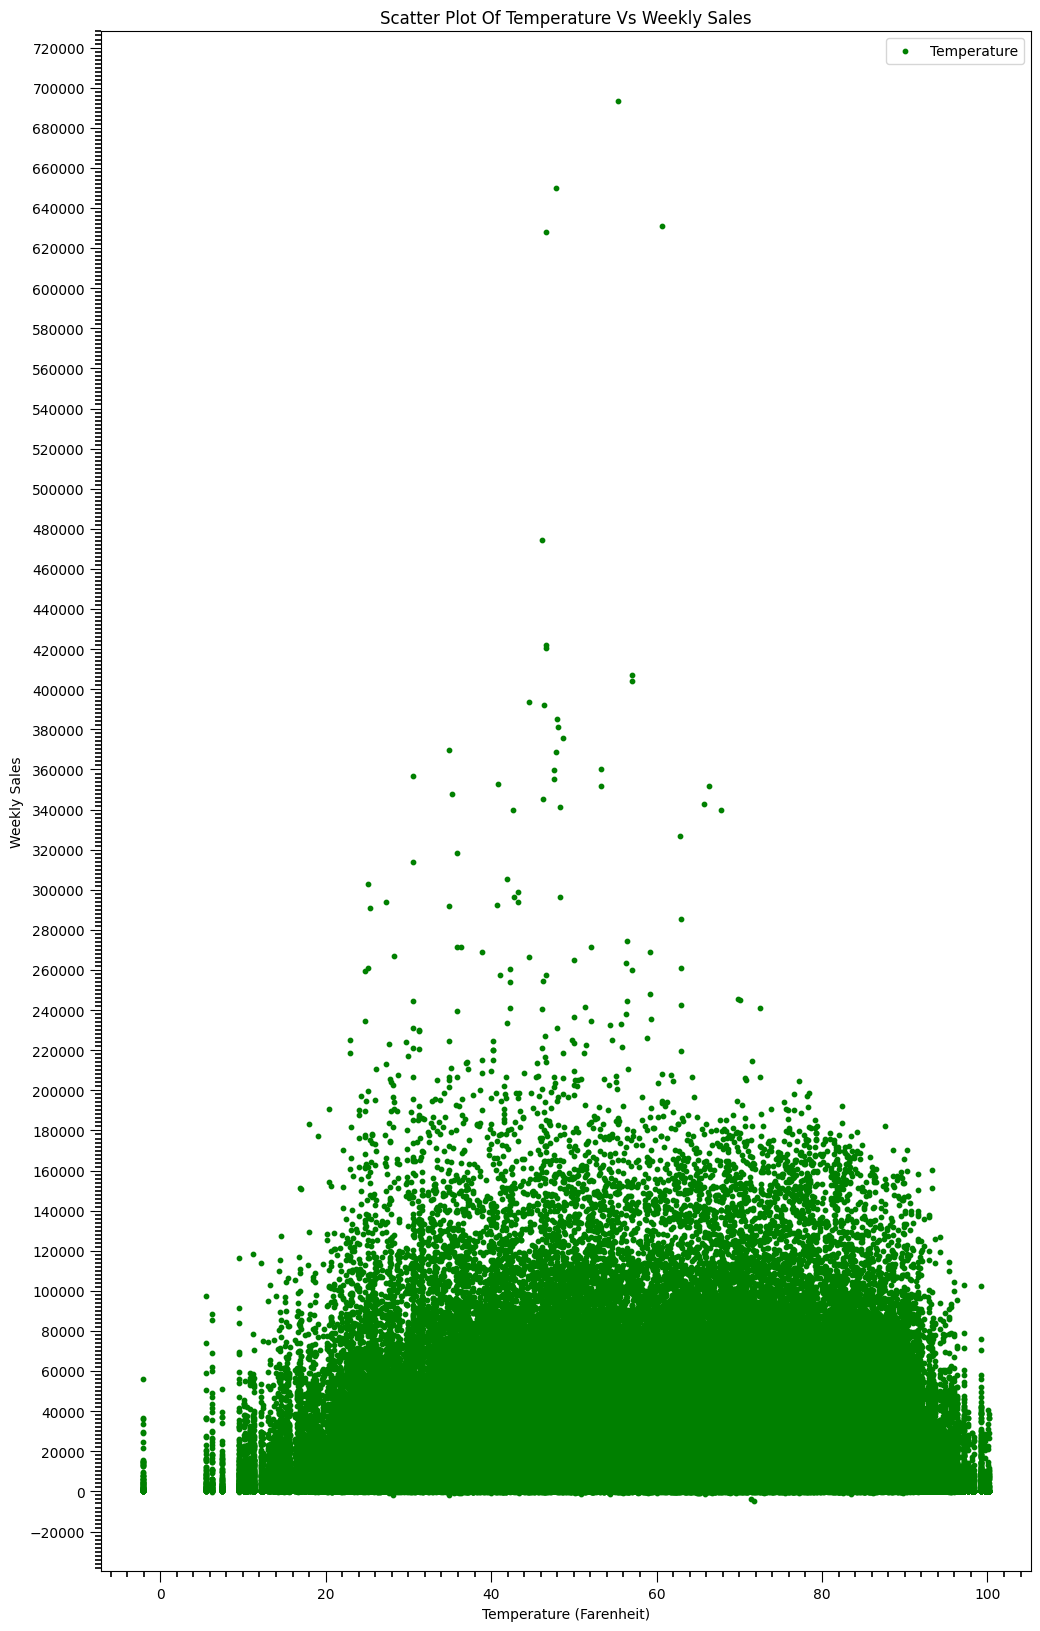

In [18]:
#used chatGPT code to get "ticks" between axis values
#however due to a lack of knowldege am running the plot first then deciding what the
#ticks values are -DOH!

#Is there a correlation between temperature and sales? 
fig, ax = plt.subplots(figsize=(12, 20))

ax.scatter(
    dfCombined_DataSet["Temperature"],
    dfCombined_DataSet["Weekly_Sales"],
    alpha=1,
    label="Temperature",
    color="green",
    s=10
)


#this code came from chatGPT and has been HEAVILY modified
# Major ticks every 20 units
ax.xaxis.set_major_locator(MultipleLocator(20))

# Minor ticks every 2 units
ax.xaxis.set_minor_locator(MultipleLocator(2))

#my added code
# Major ticks every 100000 units
ax.yaxis.set_major_locator(MultipleLocator(20000))

# Minor ticks every 2000 units
ax.yaxis.set_minor_locator(MultipleLocator(2000))

ax.tick_params(axis='y', which='minor', length=4, width=1.2)
ax.tick_params(axis='y', which='major', length=8, width=0.8)
#end of my added code


# Make minor tick marks visible
ax.tick_params(axis='x', which='minor', length=4, width=1.2)
ax.tick_params(axis='x', which='major', length=8, width=0.8)
#end of chatGPT code

#set title and labels
ax.set_title("Scatter Plot Of Temperature Vs Weekly Sales")
ax.set_xlabel("Temperature (Farenheit)")
ax.set_ylabel("Weekly Sales")
#position legend
ax.legend(loc="upper right")
#show plot!
plt.show()

